In [139]:
import pandas as pd
import re
from difflib import SequenceMatcher
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

In [154]:
cwes = ["CWE-79", "CWE-22", "CWE-89"]
models = ['mixtral']

- Usage -> define your models and skip to execution part
- The files must have structure data-CWE-XX-model.csv with following 3 headers: file_id, model_output, type (buggy, not_buggy)

# Functions

In [173]:
def import_csv(cwe_id, model):

    def _check_files(df_data, df_files):
        # check if df_data has 3 columns: file_Id with integers, model_output with text and type with buggy/not_buggy
        required_columns = {
        'file_id': 'int64',  # assuming file_id should be an integer type
        'model_output': 'object', # in pd text
        'type': 'object'  
        }

        # Check if all required columns are in df_data and have the correct data type
        for column, dtype in required_columns.items():
            assert column in df_data.columns, f"Missing column: {column}"
            assert df_data[column].dtype == dtype, f"Incorrect dtype for {column}: expected {dtype}, found {df_data[column].dtype}"

        # Check if 'type' column has only 'buggy' or 'not_buggy'
        valid_types = ['buggy', 'not_buggy']
        assert df_data['type'].isin(valid_types).all(), "Column 'type' contains invalid entries"

        
        # Expected checks
        file_ids_data = df_data['file_id'].value_counts()
        file_ids_files = df_files['file_id'].unique()

        # Check for each file_id if it appears twice in the data
        problems = []
        for file_id in file_ids_files:
            if file_id not in file_ids_data or file_ids_data[file_id] != 2:
                problems.append(file_id)
        
        # Check if the number of records in data is double the number of file_ids in files
        if len(df_data) != 2 * len(df_files):
            print(f"Data count mismatch: Expected {2 * len(df_files)}, got {len(df_data)}.")

        if problems:
            print(f"Some file_ids are missing the required number of entries in the data:")
            for file_id in problems:
                count = file_ids_data[file_id] if file_id in file_ids_data else 0

                # Uncomment to see which files are exactly missing
                # print(f"file_id {file_id}: Expected 2, Found {count}")
        else:
            print("All file_ids have the correct number of entries.")

    # File paths
    data_csv = f"data-{cwe_id}-{model}.csv"
    files_csv = f"files_{cwe_id}.csv"

    # Load data
    df_data = pd.read_csv(data_csv)
    df_files = pd.read_csv(files_csv)

    _check_files(df_data, df_files)

    # Continue processing as before
    df = pd.merge(df_data, df_files, on='file_id', how='left')
    df['file_to_use'] = df.apply(lambda row: row['file_before'] if row['type'] == 'buggy' else row['file_after'], axis=1)
    df = df[['file_to_use', 'type', 'model_output', 'patch']]

    return df


In [142]:
# Functions to work towards classification
bug_line_pattern = re.compile(r'(Bugged\s*)?[ -]*(Line|BL)\s*[:#]\s*(.*?)(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
# enhanced regrex which removes notes and matches everything up to bug found: -> not working for notes etc, but takes  abckticks into account
# bug_line_pattern = re.compile(r'BL:\s*(?:`([^`]+)`|([^`]*?))(?=BUG FOUND:)', re.IGNORECASE | re.DOTALL)
# -> now logic defines in extract_bug_lines logic

def extract_code_or_return_original(text):
    # This regex matches text enclosed in triple backticks, capturing the content after the initial language specifier.
    pattern = r"```([a-zA-Z]+)\n(.*?)```"
    matches = list(re.finditer(pattern, text, re.DOTALL))

    if not matches:
        # No code block found, return the original text
        return text

    # If matches are found, extract and return them
    results = []
    for match in matches:
        # Extract the code content, excluding the language name
        results.append(match.group(2).strip())

    # Join extracted code blocks with newlines, if there are multiple blocks
    return "\n".join(results)

def clean_whitespace(text):
    # Replace all newlines with a single space
    text = text.replace('\n', ' ')
    # Replace all sequences of whitespace with a single space
    text = re.sub(r'\s+', ' ', text)
    return text.strip().strip('`.')

def get_removed_lines(patch):
    # Extract lines starting with -
    removed_lines = re.findall(r'^-.*$', patch, re.MULTILINE)
    # Remove the leading - character from each line
    removed_lines = [line[1:] for line in removed_lines]
    return ' '.join(removed_lines)

def extract_bug_line(model_output):
    # todo maybe not right? -> look then into df's
    bug_line = re.split(bug_line_pattern, model_output, 1)[-2]
    bug_line = extract_code_or_return_original(bug_line).strip()

    # if there is a string which is in ` ` extract it, otherwise use as it is
    match = re.search(r'`([^`]+)`', bug_line)
    if match:
        bug_line =  match.group(0)  # Return content inside the backticks

    bug_line = clean_whitespace(bug_line)
    return bug_line
    
def has_bug_line(model_output):
    code = extract_code_or_return_original(model_output)

    # todo maybe none needs improvement, sometimes N/A? 
    if(bool(bug_line_pattern.search(model_output)) and 'BL: None'.lower() not in model_output.lower()):
        return True
    if code and code != model_output:
        return True
    return False

def classify(record):
    type = record['type']
    patch = record['patch']
    model_output = record['model_output']

    classification = None
    bug_line = None
    patch_removal = None

    pattern_yes = re.compile(r"bug\s*found\s*:\s*yes", re.IGNORECASE)
    pattern_no = re.compile(r"bug\s*found\s*:\s*no", re.IGNORECASE)

    # Check for matches
    has_bug_true_indication = bool(re.search(pattern_yes, model_output))
    has_bug_false_indication = bool(re.search(pattern_no, model_output))
    _has_bug_line = has_bug_line(model_output)

    # stronger conditions -> lets rely purely on model_output under Bug found
    if type == 'not_buggy' and has_bug_true_indication: 
       classification = 'FP'
    elif type == 'not_buggy' and has_bug_false_indication: 
        classification = 'TN'
    elif type == 'buggy' and has_bug_false_indication: 
        classification = 'FN'
    
    # weaker decision based in bugged_line
    elif type == 'not_buggy' and _has_bug_line:
        classification = 'FP'
    elif type == 'not_buggy' and not _has_bug_line:
        classification = 'TN'
    elif type == 'buggy' and not _has_bug_line:
        classification = 'FN'
    else:

        bug_line = extract_bug_line(model_output)
        patch_removal = clean_whitespace(get_removed_lines(patch))
        
        # TODO inspect -> now only comparision of removal in the patch, but some have additions as well -> maybe take additions also
        bug_line_in_patch = bug_line in patch_removal
        if (bug_line_in_patch):
            classification = 'TP'
        else:
            classification = 'FN' #?is this correct
        
    # return panda seried for easier debugging
    return pd.Series([classification, bug_line, patch_removal])

In [150]:
def calculate_stats(df):
    fn = df[df['classification'] == 'FN'].shape[0]
    fp = df[df['classification'] == 'FP'].shape[0]
    tn = df[df['classification'] == 'TN'].shape[0]
    tp = df[df['classification'] == 'TP'].shape[0]

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)

    print(f"Total Samples: {df.shape[0]}")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1: {f1}")

def get_first_patchline(patch):
    # Regular expression pattern to match the first -1 number in the diff
    patch_line_regexp = r'@@ -(\d+),\d+ \+\d+,\d+ @@'
    match = re.search(patch_line_regexp, patch)

    # Check if we have a match and return the first starting line number
    if match:
        return int(match.group(1))  # Convert this string number to an integer and return

    return None  # Return None if no match is found to indicate the absence of the expected pattern

def plot_logistic_regression(data, x_col, y_col, label, ax, color):
    # Prepare data: Add a constant term for the intercept
    X = sm.add_constant(data[x_col])
    y = data[y_col]
    
    # Fit logistic regression model
    model = sm.Logit(y, X).fit(disp=0)  # disp=0 suppresses fit information
    
    # Generate predictions for a range of input values
    x_values = np.linspace(data[x_col].min(), data[x_col].max(), 300)
    x_values_with_const = sm.add_constant(x_values)
    y_probs = model.predict(x_values_with_const)
    
    # Plot
    ax.plot(x_values, y_probs, label=f"{label} (p={model.pvalues[x_col]:.3f})", color=color, linewidth=2)
    
    return model

In [174]:
def prepare_df(df):
    df[['classification', 'bug_line', 'patch_removal']] = df.apply(classify, axis=1)


    # Makes manual debuging easier -> like removal of backslashes, manual assigning of TP/FN....
    df['match_score'] = df.apply(lambda row: SequenceMatcher(None, row['bug_line'], row['patch_removal']), axis=1)

    #calculate important stats for regression 
    df['file_length_chars'] = df.apply(lambda row: len(row['file_to_use']), axis=1)
    df['patch_line_first'] = df.apply(lambda row: get_first_patchline(row['patch']), axis=1)
    # todo add some average, removal of first lines etc

    return df

In [151]:
def main():
    target_variable = 'classification_TP'
    for model in models:

        fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)
        colors = ['blue', 'orange', 'green']

        for i, cwe in enumerate(cwes):
            try:
                df = import_csv(cwe, model)
            except FileNotFoundError:
                print(f"Missing file for {cwe} with {model}")
                continue
            df = prepare_df(df)

            print(f"Results for {cwe} with {model}")
            calculate_stats(df) #prints results

            # convert classification into dummies
            df = pd.get_dummies(df, columns=['classification'], drop_first=False)

            # drop NA for some files (like 1 or 2 files overall)
            df = df.dropna(subset=['patch_line_first'])
            
            plot_logistic_regression(df, 'file_length_chars', target_variable, cwe, axes[0], colors[i])
            plot_logistic_regression(df, 'patch_line_first', target_variable, cwe, axes[1], colors[i])
        
        axes[0].set_xlabel('File Size - characters')
        axes[0].set_ylabel('Probability of Finding the Bug')
        axes[0].set_title('File Size vs Probability of Finding the Bug')
        axes[0].legend()

        axes[1].set_xlabel('Bug-Line Position')
        axes[1].set_ylabel('Probability of Finding the Bug')
        axes[1].set_title('Bug-Line Position vs Probability of Finding the Bug')
        axes[1].legend()

        plt.suptitle(f'Logistic Regression Analysis of Bug Detection - {model}', fontsize=16, y=1.05)

        # Enhance layout and display plot
        plt.tight_layout()
        plt.show()

# Execution

In [175]:
# manual testing of one loop -> good for comparing responses and patch on given CWE (in jupyter variables)
df = import_csv('CWE-79', 'mixtral')
df = prepare_df(df)
calculate_stats(df)

Data count mismatch: Expected 1086, got 764.
Some file_ids are missing the required number of entries in the data:
Total Samples: 764
Accuracy: 0.12172774869109948
Precision: 0.15180722891566265
Recall: 0.1649214659685864
F1: 0.15809284818067754
Total Samples: 764
Accuracy: 0.12172774869109948
Precision: 0.15180722891566265
Recall: 0.1649214659685864
F1: 0.15809284818067754


Data count mismatch: Expected 1086, got 764.
Some file_ids are missing the required number of entries in the data:
Results for CWE-79 with mixtral
Total Samples: 764
Accuracy: 0.12172774869109948
Precision: 0.15180722891566265
Recall: 0.1649214659685864
F1: 0.15809284818067754
Missing file for CWE-22 with mixtral
Missing file for CWE-89 with mixtral


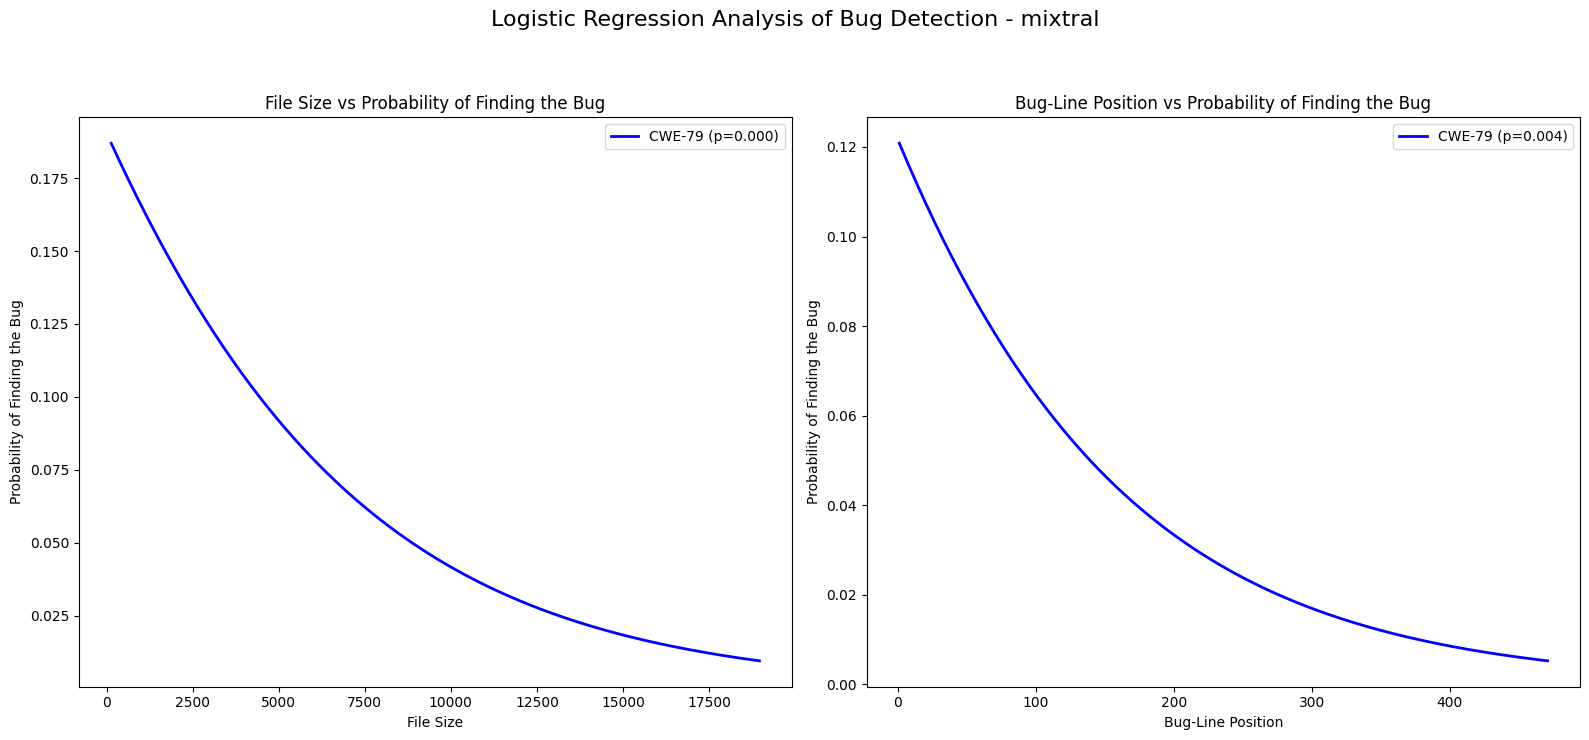

Data count mismatch: Expected 1086, got 764.
Some file_ids are missing the required number of entries in the data:
Results for CWE-79 with mixtral
Total Samples: 764
Accuracy: 0.12172774869109948
Precision: 0.15180722891566265
Recall: 0.1649214659685864
F1: 0.15809284818067754
Missing file for CWE-22 with mixtral
Missing file for CWE-89 with mixtral


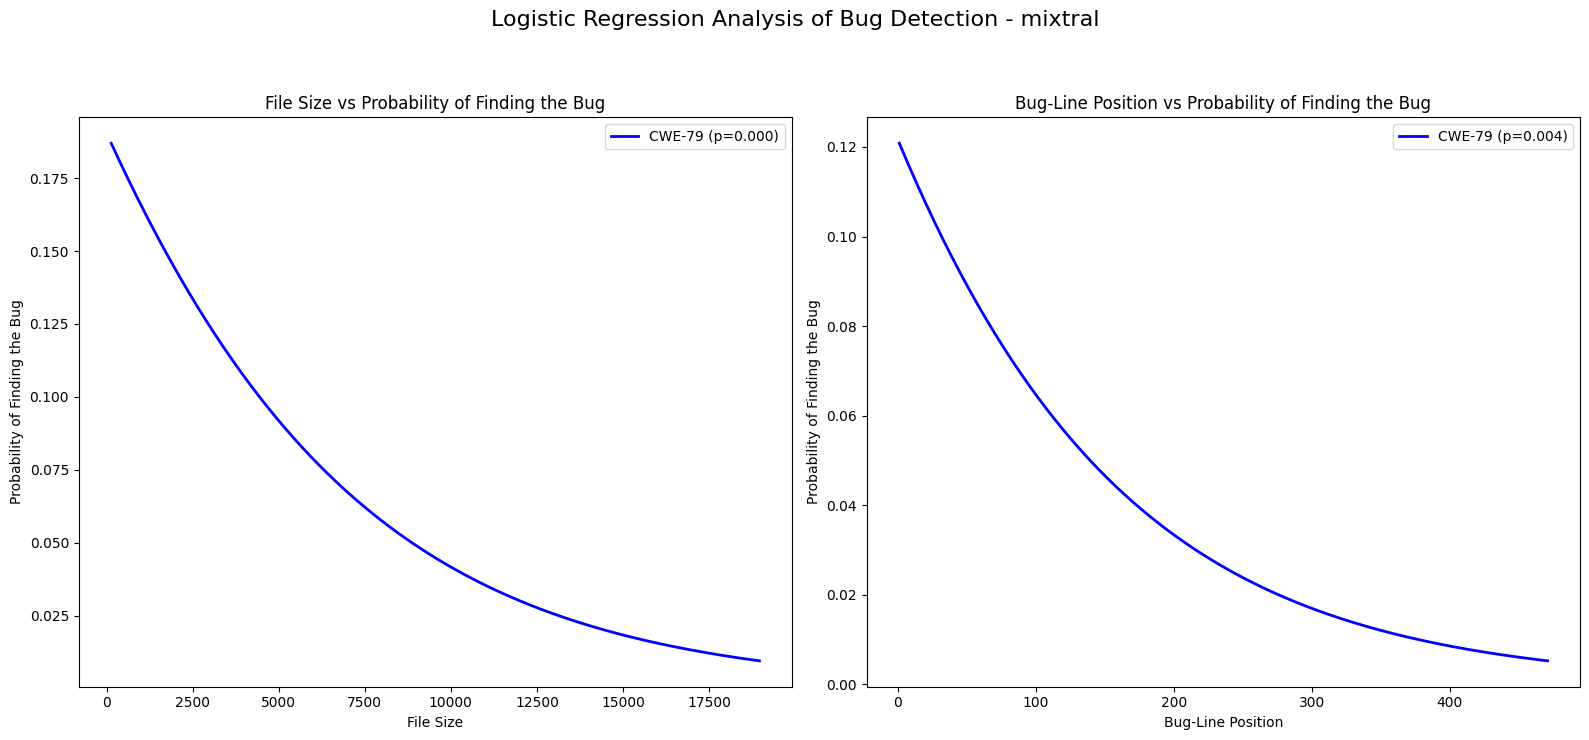

In [176]:
main()